In [1]:
# 1. Import libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.21.0


In [2]:
# 2. Set paths
# Change these paths if your files are in another folder.
STYLES_CSV = 'styles.csv'
IMAGES_CSV = 'images.csv'
IMAGE_DIR = 'images'   # folder containing 15970.jpg, 39386.jpg, etc.

OUTPUT_DIR = Path('fashion_project_outputs')
FIG_DIR = OUTPUT_DIR / 'figures_png'
TABLE_DIR = OUTPUT_DIR / 'tables_png'
MODEL_DIR = OUTPUT_DIR / 'models'
for folder in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


In [3]:
# 3. Load dataset metadata
styles_df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')
images_df = pd.read_csv(IMAGES_CSV, on_bad_lines='skip')

styles_df['id'] = styles_df['id'].astype(str)
images_df['id'] = images_df['filename'].str.replace('.jpg', '', regex=False).astype(str)

df = styles_df.merge(images_df, on='id', how='left')
df['image_path'] = df['id'].astype(str) + '.jpg'
df['image_path'] = df['image_path'].apply(lambda x: os.path.join(IMAGE_DIR, x))

df = df.dropna(subset=['articleType'])
print('Rows:', len(df))
print('Columns:', df.columns.tolist())
df.head()


Rows: 44424
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'filename', 'link', 'image_path']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,filename,link,image_path
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg,http://assets.myntassets.com/v1/images/style/p...,images\15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans,39386.jpg,http://assets.myntassets.com/v1/images/style/p...,images\39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch,59263.jpg,http://assets.myntassets.com/v1/images/style/p...,images\59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants,21379.jpg,http://assets.myntassets.com/v1/images/style/p...,images\21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt,53759.jpg,http://assets.myntassets.com/v1/images/style/p...,images\53759.jpg


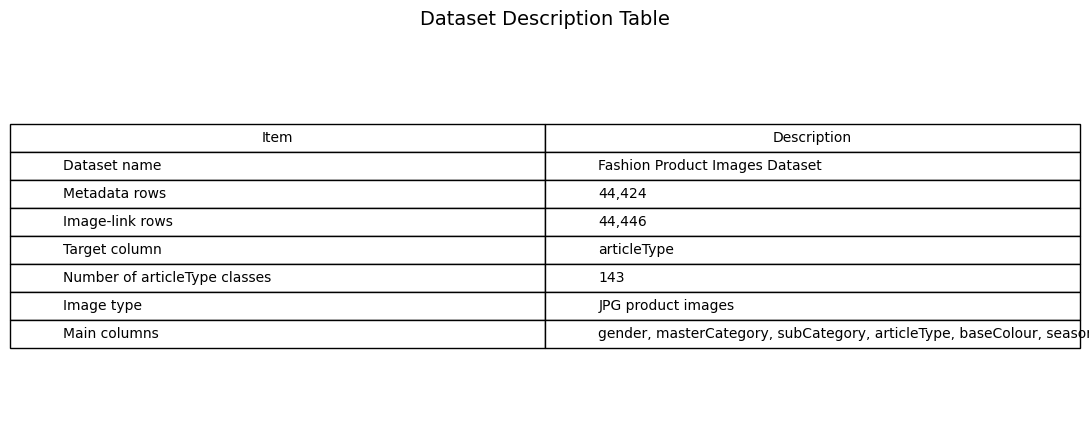

,Item,Description
0,Dataset name,Fashion Product Images Dataset
1,Metadata rows,"44,424"
2,Image-link rows,"44,446"
3,Target column,articleType
4,Number of articleType classes,143
5,Image type,JPG product images
6,Main columns,"gender, masterCategory, subCategory, articleTy..."


In [4]:
# 4. Dataset description table and PNG
summary_table = pd.DataFrame({
    'Item': [
        'Dataset name', 'Metadata rows', 'Image-link rows', 'Target column',
        'Number of articleType classes', 'Image type', 'Main columns'
    ],
    'Description': [
        'Fashion Product Images Dataset',
        f'{len(styles_df):,}',
        f'{len(images_df):,}',
        'articleType',
        df['articleType'].nunique(),
        'JPG product images',
        ', '.join(['gender','masterCategory','subCategory','articleType','baseColour','season','usage'])
    ]
})

def save_table_png(table_df, title, output_path):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.axis('off')
    tbl = ax.table(cellText=table_df.values, colLabels=table_df.columns, cellLoc='left', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 1.5)
    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches='tight')
    plt.show()

save_table_png(summary_table, 'Dataset Description Table', TABLE_DIR / 'dataset_description_table.png')
summary_table.to_csv(OUTPUT_DIR / 'dataset_description_table.csv', index=False)
summary_table


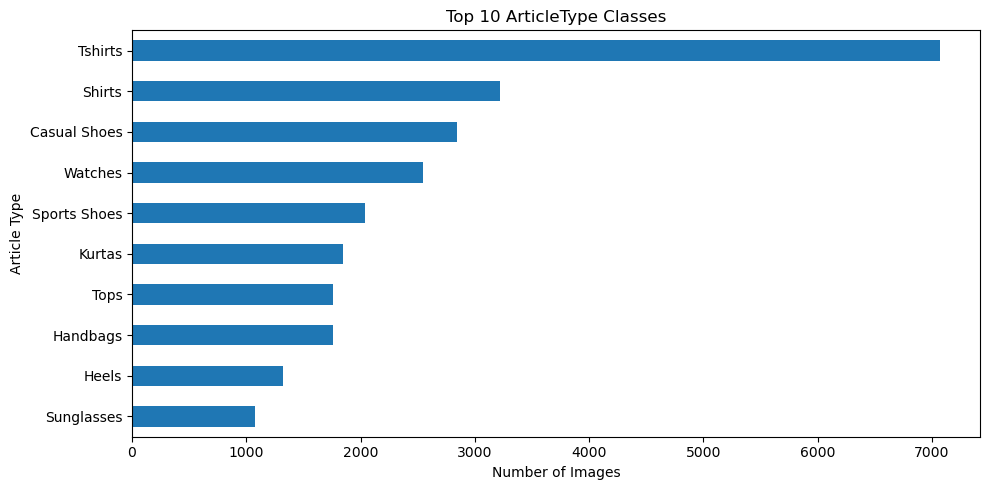

In [5]:
# 5. Class distribution chart
class_counts = df['articleType'].value_counts().head(10)
plt.figure(figsize=(10,5))
class_counts.sort_values().plot(kind='barh')
plt.title('Top 10 ArticleType Classes')
plt.xlabel('Number of Images')
plt.ylabel('Article Type')
plt.tight_layout()
plt.savefig(FIG_DIR / 'top10_class_distribution.png', dpi=200, bbox_inches='tight')
plt.show()


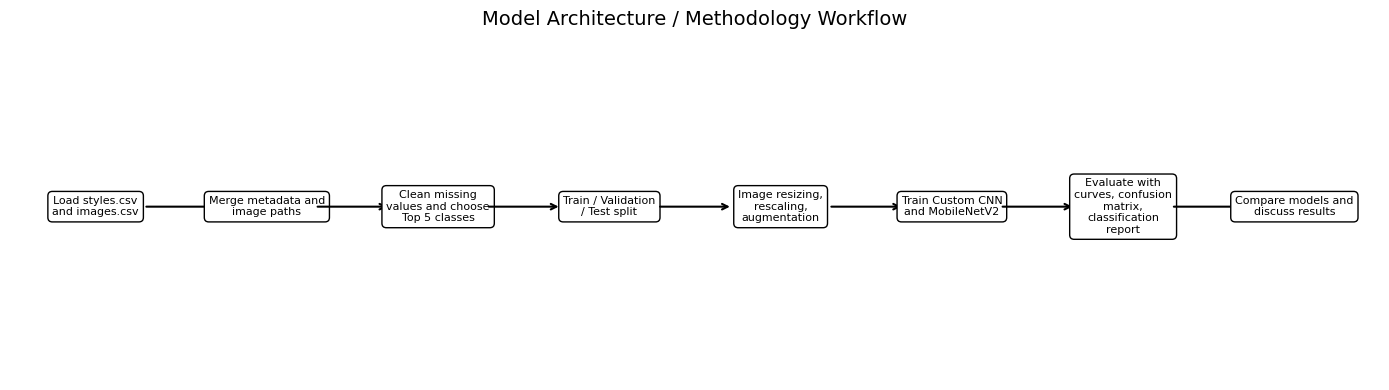

In [6]:
# 6. Create methodology workflow figure
import textwrap
steps = [
    'Load styles.csv and images.csv',
    'Merge metadata and image paths',
    'Clean missing values and choose Top 5 classes',
    'Train / Validation / Test split',
    'Image resizing, rescaling, augmentation',
    'Train Custom CNN and MobileNetV2',
    'Evaluate with curves, confusion matrix, classification report',
    'Compare models and discuss results'
]
plt.figure(figsize=(14,4))
ax = plt.gca()
ax.axis('off')
for i, step in enumerate(steps):
    ax.text(i, 0.5, '\n'.join(textwrap.wrap(step, 18)), ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='black'), fontsize=8)
    if i < len(steps)-1:
        ax.annotate('', xy=(i+0.72, 0.5), xytext=(i+0.28, 0.5), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.set_xlim(-0.5, len(steps)-0.5)
ax.set_ylim(0,1)
plt.title('Model Architecture / Methodology Workflow', fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / 'methodology_workflow_figure.png', dpi=200, bbox_inches='tight')
plt.show()


In [7]:
# 7. Keep only top 5 articleType classes and check local image files

import os

TOP_N_CLASSES = 5
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

# IMPORTANT: correct image folder
IMAGE_DIR = r"C:\Users\hites\ML PHASE II\fashion-dataset\images"

# Recreate image_path using correct folder
df["id"] = df["id"].astype(str)

df["image_path"] = df["id"].apply(
    lambda x: os.path.join(IMAGE_DIR, x + ".jpg")
)

available_df = df[df["image_path"].apply(os.path.exists)].copy()

print("Image folder exists:", os.path.exists(IMAGE_DIR))
print("Total images in folder:", len(os.listdir(IMAGE_DIR)))
print("Available local images:", len(available_df))

if len(available_df) == 0:
    raise FileNotFoundError(
        "No matching image files found. Check IMAGE_DIR and id column."
    )

top_classes = available_df["articleType"].value_counts().head(TOP_N_CLASSES).index

model_df = available_df[
    available_df["articleType"].isin(top_classes)
].copy()

print(model_df["articleType"].value_counts())

Image folder exists: True
Total images in folder: 44442
Available local images: 44419
articleType
Tshirts         7066
Shirts          3215
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Name: count, dtype: int64


In [8]:
# 8. Train / validation / test split

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["articleType"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["articleType"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 12392
Validation: 2656
Test: 2656


In [9]:
# 9. Image generators

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="articleType",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="articleType",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="articleType",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 12392 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.
Found 2656 validated image filenames belonging to 5 classes.
Classes: ['Casual Shoes', 'Shirts', 'Sports Shoes', 'Tshirts', 'Watches']
Number of classes: 5


In [10]:
# 10. Custom CNN model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Create num_classes if it is not already created
try:
    num_classes
except NameError:
    class_names = sorted(model_df["articleType"].unique())
    num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

custom_cnn = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

custom_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

custom_cnn.summary()

Classes: ['Casual Shoes', 'Shirts', 'Sports Shoes', 'Tshirts', 'Watches']
Number of classes: 5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,501 (42.61 MB)

 Trainable params: 11,170,053 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
# 11. Train Custom CNN

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pathlib import Path

# Create model folder if not already created
MODEL_DIR = Path("fashion_project_outputs/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# If custom_cnn is missing, run Cell 10 first
if "custom_cnn" not in globals():
    raise NameError("custom_cnn is not defined. Please run Cell 10: Custom CNN model first.")

# If generators are missing, run Cell 9 first
if "train_generator" not in globals() or "val_generator" not in globals():
    raise NameError("train_generator or val_generator is missing. Please run Cell 9: Image generators first.")

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=MODEL_DIR / "best_custom_cnn.keras",
        save_best_only=True,
        monitor="val_accuracy",
        mode="max"
    )
]

history_custom = custom_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 694s 2s/step - accuracy: 0.6804 - loss: 0.8852 - val_accuracy: 0.7910 - val_loss: 0.5988
Epoch 2/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 694s 2s/step - accuracy: 0.7749 - loss: 0.5777 - val_accuracy: 0.8671 - val_loss: 0.3471
Epoch 3/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - accuracy: 0.8033 - loss: 0.4918 - val_accuracy: 0.8678 - val_loss: 0.3106
Epoch 4/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 676s 2s/step - accuracy: 0.8268 - loss: 0.4311 - val_accuracy: 0.8874 - val_loss: 0.3226
Epoch 5/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 700s 2s/step - accuracy: 0.8284 - loss: 0.4292 - val_accuracy: 0.7353 - val_loss: 1.4555
Epoch 6/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.8398 - loss: 0.4020 - val_accuracy: 0.9025 - val_loss: 0.2660
Epoch 7/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 684s 2s/step - accuracy: 0.8448 - loss: 0.3793 - val_accuracy: 0.9047 - val_loss: 0.2440
Epoch 8/10
388/388 ━━━━━━━━━━━━━━━━━━━━ 700s 2s/step - accuracy: 0.8520 - loss: 0.3684 - val_accu

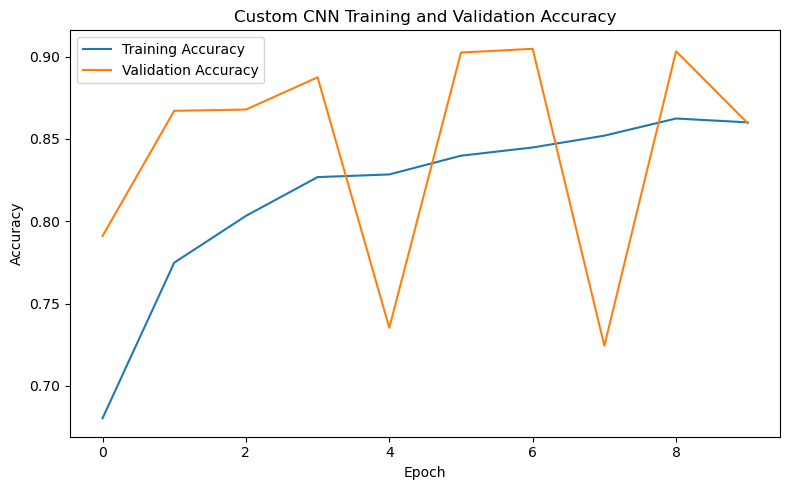

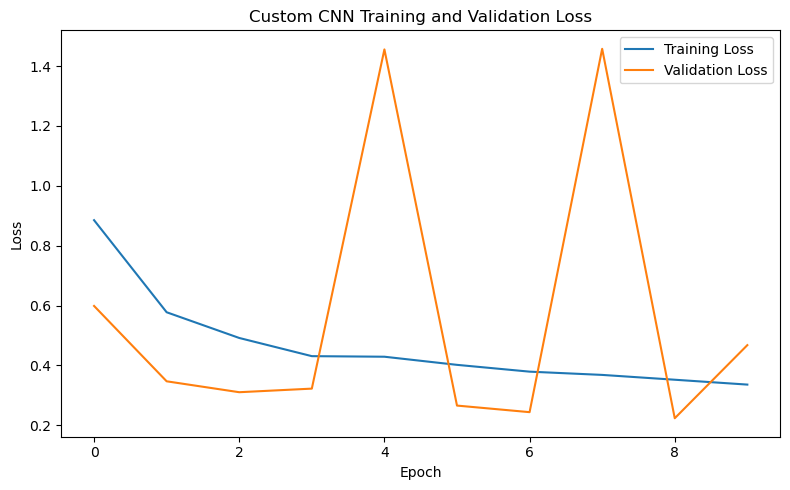

Saved:
fashion_project_outputs\figures\custom_cnn_accuracy_curve.png
fashion_project_outputs\figures\custom_cnn_loss_curve.png


In [12]:
# 12. Save training and validation curves

import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("fashion_project_outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "history_custom" not in globals():
    raise NameError("history_custom is not defined. Please run Cell 11: Train Custom CNN first.")

def plot_training_curves(history, model_name):
    model_file_name = model_name.lower().replace(" ", "_")

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Training and Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_file_name}_accuracy_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Training and Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_file_name}_loss_curve.png", dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(FIG_DIR / f"{model_file_name}_accuracy_curve.png")
    print(FIG_DIR / f"{model_file_name}_loss_curve.png")

plot_training_curves(history_custom, "Custom CNN")

In [ ]:
# 13. Confusion matrix and classification results table for Custom CNN
test_generator.reset()
y_prob = custom_cnn.predict(test_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title('Custom CNN Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'custom_cnn_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv(OUTPUT_DIR / 'custom_cnn_classification_report.csv')
save_table_png(report_df.round(3).reset_index().rename(columns={'index':'Class'}),
               'Custom CNN Classification Results Table',
               TABLE_DIR / 'custom_cnn_classification_results_table.png')
report_df


39/83 ━━━━━━━━━━━━━━━━━━━━ 39s 890ms/step 

In [ ]:
# 14. MobileNetV2 transfer learning model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)
mobilenet_model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
mobilenet_model.summary()


In [ ]:
# 15. Train MobileNetV2
callbacks_mobile = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint(MODEL_DIR / 'best_mobilenetv2.keras', save_best_only=True, monitor='val_accuracy')
]

history_mobile = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks_mobile
)

plot_training_curves(history_mobile, 'MobileNetV2')


In [ ]:
# 16. Evaluate both models and create comparison table
custom_loss, custom_acc = custom_cnn.evaluate(test_generator, verbose=0)
mobile_loss, mobile_acc = mobilenet_model.evaluate(test_generator, verbose=0)

comparison_df = pd.DataFrame({
    'Model': ['Custom CNN', 'MobileNetV2 Transfer Learning'],
    'Test Accuracy': [custom_acc, mobile_acc],
    'Test Loss': [custom_loss, mobile_loss]
})
comparison_df.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)

save_table_png(comparison_df.round(4), 'Comparison Between Models', TABLE_DIR / 'model_comparison_table.png')

plt.figure(figsize=(8,5))
plt.bar(comparison_df['Model'], comparison_df['Test Accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'model_accuracy_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
comparison_df


In [ ]:
# 17. Final output location
print('All PNG figures saved in:', FIG_DIR)
print('All PNG tables saved in:', TABLE_DIR)
print('CSV tables and models saved in:', OUTPUT_DIR)
